# Practical 2 — Probabilistic Modeling and Synthetic Data

**Enrollment:** BT24S05F007

## Aim
Use a Gaussian distribution to describe data, draw synthetic samples from it, and check that the samples recover the parameters that created them.

## Idea
A Gaussian is fixed by a center (the mean) and a spread (the variance, or a covariance matrix when there are two features). Once those numbers are chosen, new rows of data can be drawn without collecting them from the real world. Plotting the probability density function next to a histogram shows whether the samples follow the curve that was specified.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

rng = np.random.default_rng(24)


## One feature
Quiz scores are modeled as a Gaussian with mean 68 and standard deviation 9. The black curve is the probability density. The bars are 2,000 scores drawn from that same distribution.


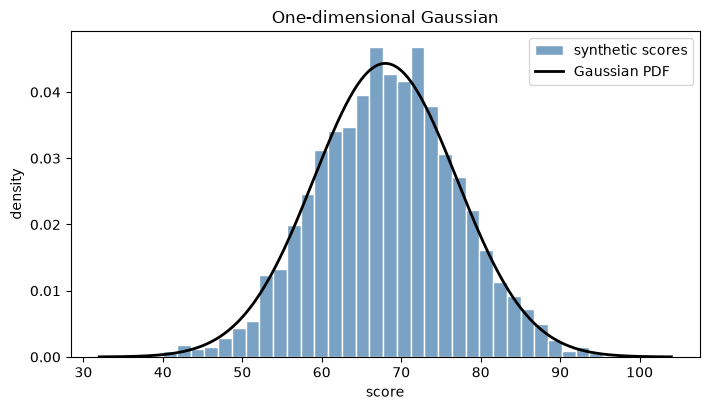

Specified mean and std: 68.00, 9.00
Sample mean and std:    68.24, 8.84
Absolute error in mean: 0.24


In [2]:
score_mean = 68.0
score_spread = 9.0
sample_count = 2000
scores = rng.normal(score_mean, score_spread, size=sample_count)

grid = np.linspace(score_mean - 4 * score_spread, score_mean + 4 * score_spread, 400)
density = (
    1.0 / (score_spread * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((grid - score_mean) / score_spread) ** 2)
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(scores, bins=32, density=True, color="#7aa2c4", edgecolor="white", label="synthetic scores")
ax.plot(grid, density, color="black", linewidth=2, label="Gaussian PDF")
ax.set_xlabel("score")
ax.set_ylabel("density")
ax.set_title("One-dimensional Gaussian")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Specified mean and std: {score_mean:.2f}, {score_spread:.2f}")
print(f"Sample mean and std:    {scores.mean():.2f}, {scores.std(ddof=1):.2f}")
print(f"Absolute error in mean: {abs(scores.mean() - score_mean):.2f}")


## Two features
Study hours and a practice-test score are drawn together. They are correlated: more hours go with a higher score, so the cloud tilts. The contour lines are the probability density of the 2D Gaussian. The dots are 1,200 synthetic students.


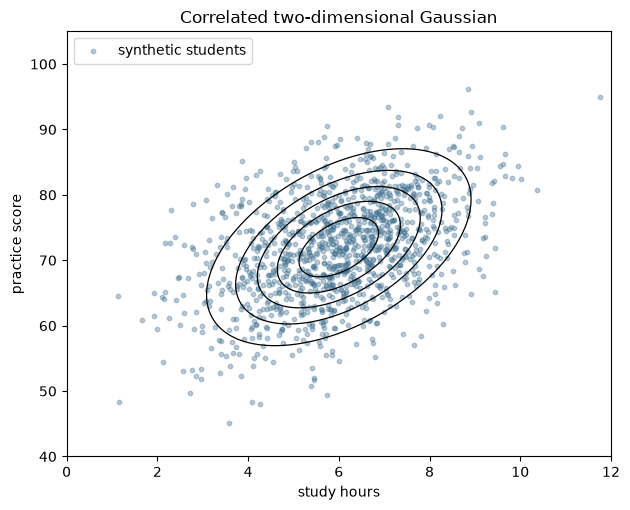

Specified mean:      [ 6. 72.]
Sample mean:         [ 5.981 71.984]
Specified covariance:
 [[ 2.4  6. ]
 [ 6.  64. ]]
Sample covariance:
 [[ 2.371  5.443]
 [ 5.443 62.321]]
Mean absolute covariance error: 0.705207166608016


In [3]:
center = np.array([6.0, 72.0])
covariance = np.array([
    [2.4, 6.0],
    [6.0, 64.0],
])
students = rng.multivariate_normal(center, covariance, size=1200)

hours_axis = np.linspace(0, 12, 160)
score_axis = np.linspace(40, 105, 160)
hours_grid, score_grid = np.meshgrid(hours_axis, score_axis)
points = np.dstack((hours_grid, score_grid))

inverse_cov = np.linalg.inv(covariance)
offset = points - center
mahalanobis = np.einsum("...i,ij,...j->...", offset, inverse_cov, offset)
determinant = np.linalg.det(covariance)
density_2d = np.exp(-0.5 * mahalanobis) / (2 * np.pi * np.sqrt(determinant))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(students[:, 0], students[:, 1], s=10, alpha=0.35, color="#3d6f8f", label="synthetic students")
ax.contour(hours_grid, score_grid, density_2d, levels=6, colors="black", linewidths=0.9)
ax.set_xlabel("study hours")
ax.set_ylabel("practice score")
ax.set_title("Correlated two-dimensional Gaussian")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

sample_center = students.mean(axis=0)
sample_covariance = np.cov(students, rowvar=False)
print("Specified mean:     ", np.round(center, 3))
print("Sample mean:        ", np.round(sample_center, 3))
print("Specified covariance:\n", np.round(covariance, 3))
print("Sample covariance:\n", np.round(sample_covariance, 3))
print("Mean absolute covariance error:", np.mean(np.abs(sample_covariance - covariance)))


## A labeled synthetic dataset
Two groups are created by sampling two different Gaussians. Group 0 is a morning batch. Group 1 is an evening batch, with a higher hour-count and a slightly lower score. No real table was collected; every row comes from the distributions below.


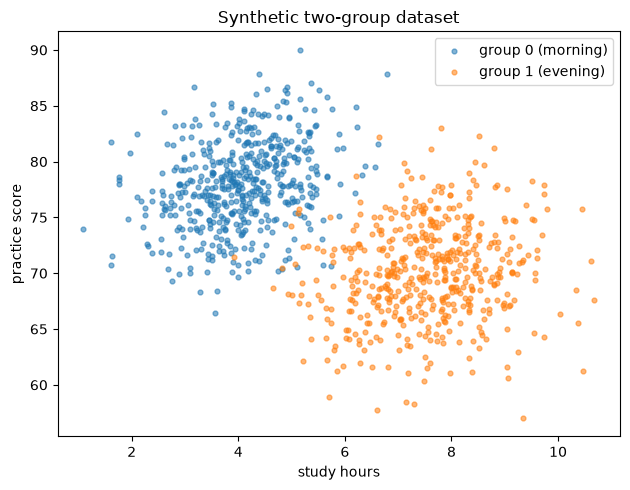

Synthetic table shape: (1000, 2)
Group counts: {0: 500, 1: 500}
Morning mean hours/score: [ 4.06 77.97]
Evening mean hours/score: [ 7.53 70.08]


In [4]:
per_group = 500
morning = rng.multivariate_normal(
    [4.0, 78.0],
    [[0.8, 1.2], [1.2, 16.0]],
    size=per_group,
)
evening = rng.multivariate_normal(
    [7.5, 70.0],
    [[1.1, 0.4], [0.4, 20.0]],
    size=per_group,
)

features = np.vstack([morning, evening])
group = np.array([0] * per_group + [1] * per_group)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(morning[:, 0], morning[:, 1], s=12, alpha=0.55, label="group 0 (morning)")
ax.scatter(evening[:, 0], evening[:, 1], s=12, alpha=0.55, label="group 1 (evening)")
ax.set_xlabel("study hours")
ax.set_ylabel("practice score")
ax.set_title("Synthetic two-group dataset")
ax.legend()
plt.tight_layout()
plt.show()

print("Synthetic table shape:", features.shape)
print("Group counts:", {int(g): int((group == g).sum()) for g in (0, 1)})
print("Morning mean hours/score:", np.round(morning.mean(axis=0), 2))
print("Evening mean hours/score:", np.round(evening.mean(axis=0), 2))


## Conclusion
Choosing a mean and a covariance fully specifies a Gaussian. Samples drawn from it land on the density curve, and the mean and covariance computed from those samples sit close to the numbers that were specified. The same procedure builds a labeled table: each class is its own Gaussian, and the scatter plot shows the two clouds the model was told to create.


## Run results

These are the values and figures produced when the notebook was executed.

```
Specified mean and std: 68.00, 9.00
Sample mean and std:    68.24, 8.84
Absolute error in mean: 0.24
```

```
Specified mean:      [ 6. 72.]
Sample mean:         [ 5.981 71.984]
Specified covariance:
 [[ 2.4  6. ]
 [ 6.  64. ]]
Sample covariance:
 [[ 2.371  5.443]
 [ 5.443 62.321]]
Mean absolute covariance error: 0.705207166608016
```

```
Synthetic table shape: (1000, 2)
Group counts: {0: 500, 1: 500}
Morning mean hours/score: [ 4.06 77.97]
Evening mean hours/score: [ 7.53 70.08]
```

**gaussian 1d**

![gaussian 1d](results/GenAI_Practical_02_gaussian_1d.png)

**gaussian 2d**

![gaussian 2d](results/GenAI_Practical_02_gaussian_2d.png)

**synthetic groups**

![synthetic groups](results/GenAI_Practical_02_synthetic_groups.png)
